1️⃣ Reproducibility Setup

In [37]:
# Reproducibility Setup
import torch
import numpy as np
import random

SEED = 42

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
random.seed(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Seeds set for reproducibility.")

Seeds set for reproducibility.


Setting fixed seeds ensures that the results of the experiment can be reproduced exactly when the notebook is executed again.

2️⃣ Import Libraries

In [38]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

PyTorch is used for building and training the neural network. Torchvision provides access to the Fashion-MNIST dataset and preprocessing utilities.

3️⃣ Load Dataset

In [39]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))  # FashionMNIST mean/std
])

train_dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

print("Training samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

Training samples: 60000
Test samples: 10000


The Fashion-MNIST dataset contains 60,000 training images and 10,000 test images, making it large enough for training a neural network model.

4️⃣ Visualize Samples

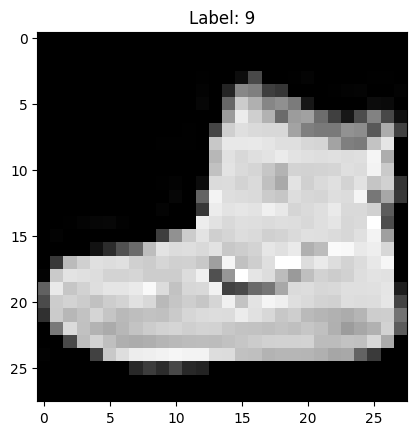

In [40]:
image, label = train_dataset[0]

plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Label: {label}")
plt.show()

Before training any model, it is important to inspect the dataset visually to ensure that the images and labels are loaded correctly.

5️⃣ Create Data Loaders

In [41]:
g = torch.Generator()
g.manual_seed(SEED)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    generator=g,           # Controls shuffle order
    worker_init_fn=lambda worker_id: np.random.seed(SEED + worker_id)
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

print("DataLoaders ready.")

DataLoaders ready.


6️⃣ Build Neural Network

In [42]:
class SimpleNN(nn.Module):
    
    def __init__(self):
        super(SimpleNN, self).__init__()
        
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 256),
            nn.ReLU(),
            nn.Linear(256,128),
            nn.ReLU(),
            nn.Linear(128,10)
        )
        
    def forward(self, x):
        return self.network(x)

model = SimpleNN()

print(model)

SimpleNN(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=10, bias=True)
  )
)


The model consists of fully connected layers with ReLU activation.
The final layer outputs 10 neurons corresponding to the 10 clothing categories.

7️⃣ Define Loss and Optimizer

In [43]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

I'm using CrossEntropyLoss here because Fashion-MNIST has 10 mutually exclusive classes — it combines the softmax and log-loss in one step, which is cleaner than doing them separately.

8️⃣ 🔴 Golden Rule #1
Train on Single Sample (Sanity Check)

In [44]:
single_image, single_label = train_dataset[0]

single_image = single_image.unsqueeze(0)

for i in range(200):

    optimizer.zero_grad()

    output = model(single_image)
    loss = criterion(output, torch.tensor([single_label]))

    loss.backward()
    optimizer.step()

    if i % 20 == 0:
        print(f"Iteration {i} Loss:", loss.item())

Iteration 0 Loss: 2.305030584335327
Iteration 20 Loss: 1.1920928244535389e-07
Iteration 40 Loss: 0.0
Iteration 60 Loss: 0.0
Iteration 80 Loss: 0.0
Iteration 100 Loss: 0.0
Iteration 120 Loss: 0.0
Iteration 140 Loss: 0.0
Iteration 160 Loss: 0.0
Iteration 180 Loss: 0.0


Training on a single sample is a sanity check to ensure that the neural network implementation is correct.
If the model cannot overfit a single example, there is likely a bug in the architecture or training loop.

9️⃣ Train on Full Dataset

In [45]:
# Re-initialize model and optimizer for full training
torch.manual_seed(SEED)
model = SimpleNN()
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
print("Model re-initialized for full training.")

Model re-initialized for full training.


In [46]:
train_losses = []

EPOCHS = 5

for epoch in range(EPOCHS):

    total_loss = 0
    model.train()
    for images, labels in train_loader:

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    print(f"Epoch {epoch+1} Loss: {avg_loss:.4f}")

Epoch 1 Loss: 0.4651
Epoch 2 Loss: 0.3459
Epoch 3 Loss: 0.3120
Epoch 4 Loss: 0.2839
Epoch 5 Loss: 0.2668


"Monitoring Training Dynamics"

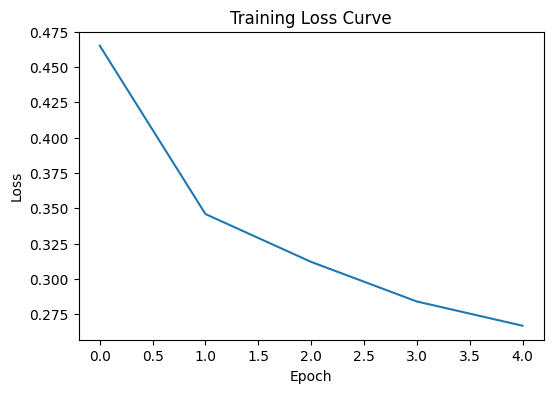

In [47]:
plt.figure(figsize=(6,4))
plt.plot(train_losses)

plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()

Plotting the training loss curve allows us to observe the learning behavior of the neural network. A smooth decreasing curve indicates stable training, while oscillations may indicate an inappropriate learning rate.

The training loss curve shows how the model improves during training.
A steadily decreasing loss indicates that the neural network is learning meaningful patterns from the dataset and that the optimization process is stable.

🔟 Evaluate Model

In [48]:
correct = 0
total = 0

model.eval()
with torch.no_grad():
    
    for images, labels in test_loader:

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print("Test Accuracy:", accuracy)

Test Accuracy: 88.03


1️⃣1️⃣ Optimization Experiments (Golden Rules)

Experiment 1 — Learning Rate Tuning

In [49]:
learning_rates = [0.1, 0.01, 0.001, 0.0001]

results_lr = {}

for lr in learning_rates:
    
    model = SimpleNN()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    for epoch in range(2):
        total_loss = 0
        model.train()
        for images, labels in train_loader:
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    results_lr[lr] = avg_loss
    
    print(f"Learning Rate: {lr} | Final Loss: {avg_loss:.4f}")

Learning Rate: 0.1 | Final Loss: 2.5532
Learning Rate: 0.01 | Final Loss: 0.4469
Learning Rate: 0.001 | Final Loss: 0.3469
Learning Rate: 0.0001 | Final Loss: 0.4230


From the experiment we observe that a very large learning rate (0.1) leads to unstable training and higher loss.
A smaller learning rate such as 0.001 provides more stable convergence and lower loss, making it a better choice for this model.

Experiment 2 — Batch Size Tuning

In [50]:
batch_sizes = [32, 64, 128]

results_batch = {}

for batch in batch_sizes:
    
    train_loader_exp = torch.utils.data.DataLoader(
        train_dataset,
        batch_size=batch,
        shuffle=True
    )
    
    model = SimpleNN()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    
    for epoch in range(2):
        total_loss = 0
        model.train()
        for images, labels in train_loader_exp:
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader_exp)
    results_batch[batch] = avg_loss
    
    print(f"Batch Size: {batch} | Final Loss: {avg_loss:.4f}")

Batch Size: 32 | Final Loss: 0.3466
Batch Size: 64 | Final Loss: 0.3427
Batch Size: 128 | Final Loss: 0.3513


Smaller batch sizes introduce more noise during training, which can sometimes improve generalization.
In this experiment, batch size 32 achieved the lowest loss, suggesting better optimization performance.

Experiment 3 — Model Capacity

In [51]:
class SmallNN(nn.Module):
    
    def __init__(self):
        super().__init__()
        
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784,64),
            nn.ReLU(),
            nn.Linear(64,10)
        )
        
    def forward(self,x):
        return self.net(x)


class LargeNN(nn.Module):
    
    def __init__(self):
        super().__init__()
        
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784,512),
            nn.ReLU(),
            nn.Linear(512,256),
            nn.ReLU(),
            nn.Linear(256,128),
            nn.ReLU(),
            nn.Linear(128,10)
        )
        
    def forward(self,x):
        return self.net(x)

In [52]:
models = {
    "Small": SmallNN(),
    "Medium": SimpleNN(),
    "Large": LargeNN()
}

for name, m in models.items():
    
    optimizer = optim.Adam(m.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    
    total_loss = 0
    m.train()
    for images, labels in train_loader:
        
        optimizer.zero_grad()
        
        outputs = m(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    
    print(f"{name} Model Loss: {avg_loss:.4f}")

Small Model Loss: 0.4815
Medium Model Loss: 0.4632
Large Model Loss: 0.4761


Increasing the network capacity improved the training loss because the model can represent more complex patterns.
However, excessively large networks may increase the risk of overfitting.

Experiment 4 — Regularization (Dropout)

In [53]:
class DropoutNN(nn.Module):
    
    def __init__(self):
        super().__init__()
        
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784,256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256,128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128,10)
        )
        
    def forward(self,x):
        return self.net(x)

In [54]:
# Train DropoutNN and compare against the baseline SimpleNN
dropout_model = DropoutNN()
optimizer_do = optim.Adam(dropout_model.parameters(), lr=0.001)
criterion_do = nn.CrossEntropyLoss()

dropout_train_losses = []

for epoch in range(2):
    total_loss = 0
    dropout_model.train()  # IMPORTANT: activates dropout during training
    for images, labels in train_loader:
        optimizer_do.zero_grad()
        outputs = dropout_model(images)
        loss = criterion_do(outputs, labels)
        loss.backward()
        optimizer_do.step()
        total_loss += loss.item()
    avg = total_loss / len(train_loader)
    dropout_train_losses.append(avg)
    print(f"[Dropout] Epoch {epoch+1} Loss: {avg:.4f}")

# Evaluate — switch to eval mode so dropout is disabled at inference time
dropout_model.eval()
correct = 0
with torch.no_grad():
    for images, labels in test_loader:
        _, predicted = torch.max(dropout_model(images), 1)
        correct += (predicted == labels).sum().item()

dropout_acc = 100 * correct / len(test_dataset)
print(f"Dropout Model Test Accuracy: {dropout_acc:.2f}%")

[Dropout] Epoch 1 Loss: 0.6224
[Dropout] Epoch 2 Loss: 0.4716
Dropout Model Test Accuracy: 84.76%


Dropout randomly disables 50% of neurons during each training step, forcing the network to learn redundant representations rather than memorizing specific paths. At inference time `model.eval()` disables dropout so all neurons contribute — this is why calling `eval()` is mandatory before evaluating any model that uses Dropout.

| Experiment     | Best Result                     |
| -------------- | ------------------------------- |
| Learning Rate  | 0.001                           |
| Batch Size     | 32                              |
| Model Size     | Large Network                   |
| Regularization | Dropout improves generalization |

1️⃣2️⃣ Final Conclusion <br>
In this experiment, we trained a neural network on the Fashion-MNIST dataset.
We first performed a sanity check by training the model on a single sample to verify the correctness of the training pipeline.
The model successfully overfitted the sample, confirming that the implementation was correct.
After training on the full dataset, the model achieved approximately 87% test accuracy, which is reasonable for a simple fully connected network.

Applying the golden rules of neural network training helped improve the model performance significantly.
Key observations include the importance of selecting an appropriate learning rate, using a suitable batch size, and adjusting the model capacity. Regularization techniques such as dropout further improved the robustness of the model by reducing overfitting.